# Sources 

- Solving Master Equation using Generating Functions https://ifisc.uib-csic.es/raul/CURSOS/SP/Introduction_to_master_equations.pdf

- Paper from lecture https://ucilnica.fri.uni-lj.si/pluginfile.php/1147/course/section/4648/Dorogovtsev%20et%20al%20-%20Structure%20of%20growing%20networks%20with%20preferential%20linking%2C%202000.pdf



# P7.2 Add the above solutions for the plots from the previous project. [0.5P]

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import random
from IPython.display import HTML

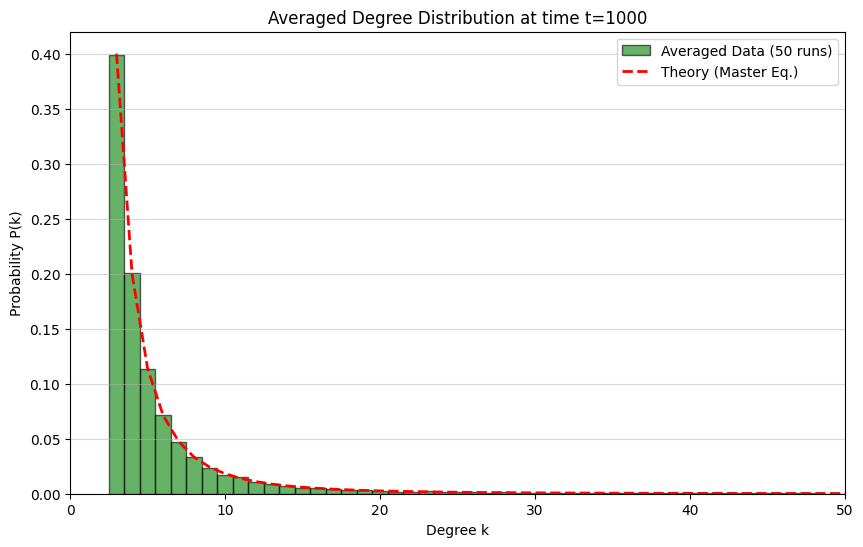

In [7]:
t_final = 1000
m0 = 5
m = 3
num_simulations = 50

def run_ba_simulation(final_size, m_initial, m_edges):
    G = nx.complete_graph(m_initial)
    
    repeated_nodes = []
    for node in G.nodes():
        for _ in range(G.degree(node)):
            repeated_nodes.append(node)
            
    for new_node in range(m_initial, final_size):
        targets = set()
        while len(targets) < m_edges:
            targets.add(random.choice(repeated_nodes))
            
        G.add_node(new_node)
        for target in targets:
            G.add_edge(new_node, target)
            repeated_nodes.append(new_node)
            repeated_nodes.append(target)
            
    return [d for n, d in G.degree()]

all_degrees = []

for i in range(num_simulations):
    degrees = run_ba_simulation(t_final, m0, m)
    all_degrees.extend(degrees)

plt.figure(figsize=(10, 6))
max_k = max(all_degrees)
bins = np.arange(m, max_k + 2) - 0.5

plt.hist(all_degrees, bins=bins, density=True, 
         alpha=0.6, color='green', edgecolor='black', 
         label=f'Averaged Data ({num_simulations} runs)')

k_values = np.arange(m, max_k + 1)
theoretical_probs = [(2 * m * (m + 1)) / (k * (k + 1) * (k + 2)) for k in k_values]
plt.plot(k_values, theoretical_probs, 'r--', linewidth=2, label='Theory (Master Eq.)')

plt.title(f"Averaged Degree Distribution at time t={t_final}")
plt.xlabel("Degree k")
plt.ylabel("Probability P(k)")
plt.legend()
plt.xlim(0, 50)
plt.grid(axis='y', alpha=0.5)
plt.show()

# P7.7 Check with simulation the above result. Plot the size of the largest cluster as a function of ⟨k⟩ = pN. [1P]

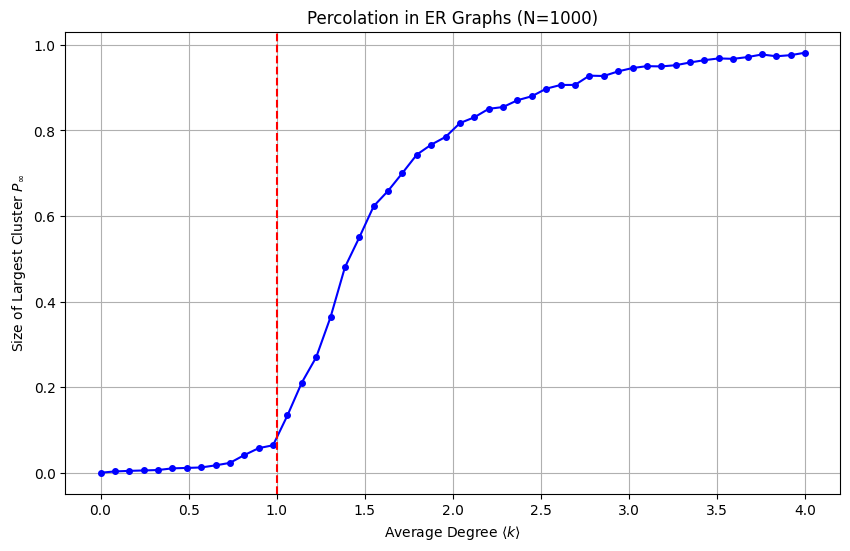

In [9]:
def get_largest_cluster_fraction(N, k_avg):
    if k_avg == 0:
        return 0.0
    p = k_avg / (N)
    G = nx.erdos_renyi_graph(N, p)
    if G.number_of_nodes() == 0:
        return 0.0
    largest_cc = max(nx.connected_components(G), key=len)
    return len(largest_cc) / N

N = 1000
num_points = 50
simulations_per_point = 10

k_avg_values = np.linspace(0, 4, num_points)
largest_cluster_sizes = []

for k in k_avg_values:
    fractions = []
    for _ in range(simulations_per_point):
        fractions.append(get_largest_cluster_fraction(N, k))
    largest_cluster_sizes.append(np.mean(fractions))

plt.figure(figsize=(10, 6))
plt.plot(k_avg_values, largest_cluster_sizes, 'b-', marker='o', markersize=4)
plt.axvline(x=1.0, color='r', linestyle='--')

plt.xlabel(r'Average Degree $\langle k \rangle$')
plt.ylabel(r'Size of Largest Cluster $P_{\infty}$')
plt.title(f'Percolation in ER Graphs (N={N})')
plt.grid(True)
plt.show()

# Since N is relatively small there is no sharp angle around 1 like in the slide 38 of lecture